# NVDA — Introducing the Agentic Predictor

> **Part 2 of 6.** Builds on [`01_nvda_case_study.ipynb`](01_nvda_case_study.ipynb).
> Next: [`03_one_agent_two_tasks.ipynb`](03_one_agent_two_tasks.ipynb).

Notebook 1 showed that a price-only model treats every NVDA shock as noise. This notebook
puts a **news-grounded analyst agent** next to the two baselines and zooms in on two
forecast origins where the news mattered most.

**The agent.** One LLM (`gemini-3.1-flash-lite-preview`, the project's lite model) with an
NVDA analyst identity and one tool, `search_web`. Every search is **fenced at the
origin**: it may only return information published before the forecast date, and an
independent verifier on a second model audits each result. A deterministic filter then
drops any sentence dated on or after the cutoff. The agent sees five years of weekly
prices plus recent daily closes, and returns 5/10/21-day price quantiles with a written
rationale.

**The two origins** (both Monday forecasts, made before the open):

| Origin | What was about to happen |
|---|---|
| **2025-01-27** | The DeepSeek sell-off: NVDA fell 17% that day |
| **2025-04-07** | The Monday after the tariff crash; the 90-day pause rally (+18.7%) came two days later |

> Every forecast here is read from the committed 2025 backtest; nothing calls an LLM.

In [1]:
import warnings
from datetime import datetime


warnings.filterwarnings("ignore")

import pandas as pd
from ai_stocks_forecasting.charts import load_scored_frame
from ai_stocks_forecasting.data import NVDA_SERIES_ID, build_nvda_service
from ai_stocks_forecasting.story import agent_rationale, origin_fan


pd.set_option("display.width", 160)
data_service = build_nvda_service()
prices = data_service.get_series(NVDA_SERIES_ID, as_of=datetime.now())
frame = load_scored_frame("nvda_backtest", data_service)
PREDICTORS = ["Naive (last value)", "AutoARIMA (log returns)", "News agent"]
COLUMNS = ["predictor", "horizon", "forecast_date", "q10", "q50", "q90", "actual", "crps"]


def scores_at(origin: str) -> pd.DataFrame:
    rows = frame[frame["as_of"] == origin][COLUMNS].sort_values(["horizon", "predictor"])
    return rows.round(2).reset_index(drop=True)

---

## 1. January 27, 2025 — the morning of the DeepSeek sell-off

DeepSeek had released its R1 reasoning model a week earlier (January 20). Over the
weekend it climbed the app-store charts, and on Monday the market repriced the whole AI
hardware trade. The forecasts below were made before that session opened.

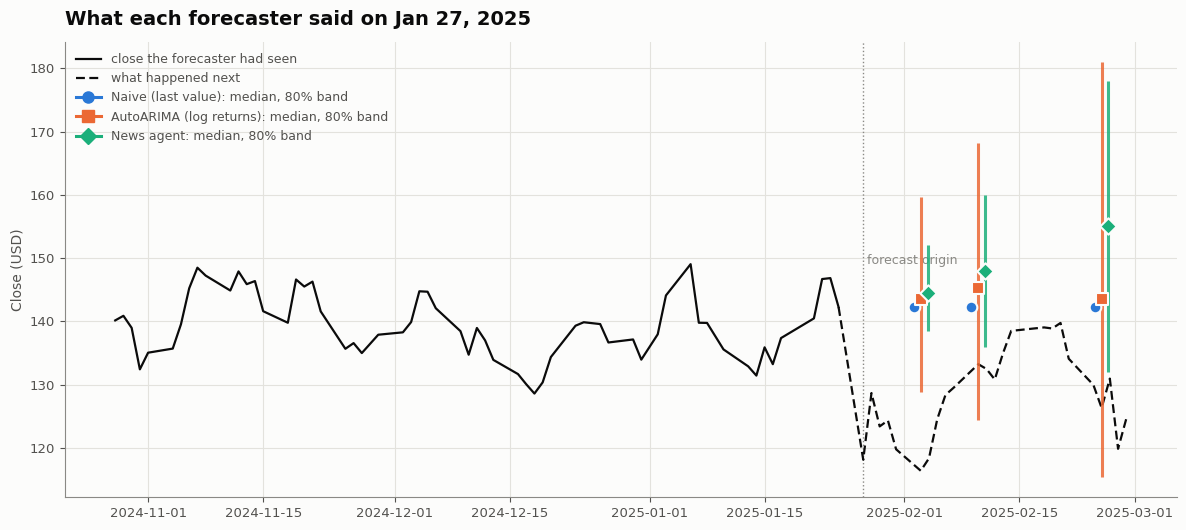

In [2]:
fig, ax = origin_fan(frame, prices, "2025-01-27", predictors=PREDICTORS)

In [3]:
scores_at("2025-01-27")

,predictor,horizon,forecast_date,q10,q50,q90,actual,crps
0,AutoARIMA (log returns),5,2025-02-03,128.74,143.53,159.62,116.36,20.63
1,Naive (last value),5,2025-02-03,142.25,142.25,142.25,116.36,25.89
2,News agent,5,2025-02-03,138.50,144.50,152.00,116.36,25.35
3,AutoARIMA (log returns),10,2025-02-10,124.47,145.31,168.21,133.22,7.60
4,Naive (last value),10,2025-02-10,142.25,142.25,142.25,133.22,9.03
5,News agent,10,2025-02-10,136.00,148.00,160.00,133.22,9.58
6,AutoARIMA (log returns),21,2025-02-25,115.44,143.50,180.96,126.30,11.26
7,Naive (last value),21,2025-02-25,142.25,142.25,142.25,126.30,15.95
8,News agent,21,2025-02-25,132.00,155.00,178.00,126.30,18.72


In [4]:
print(agent_rationale("agent_predictor_nvda_analyst_multitask", "2025-01-27"))

NVDA maintains a strong fundamental position, underpinned by dominant market share in the AI GPU space. While short-term trading is marked by volatility and consolidation following recent peaks in mid-January, the medium-term outlook remains positive due to persistent supply-constrained demand for Blackwell architectures and ongoing hyperscaler investment.


**What the agent did.** It forecast a *rise* (5-day median \$144.50 against a \$142.25
close) with a narrow band, \$138.50–\$152. The price fell to \$116. Its rationale talks
about Blackwell demand and hyperscaler spending, and never mentions DeepSeek. Its 5-day
CRPS (25.4) is worse than AutoARIMA's (20.6): a confident wrong forecast scores worse
than a vague one.

---

## 2. April 7, 2025 — after the tariff crash

NVDA had fallen 7.8% and 7.4% on the two sessions after the April 2 tariff announcement.
On April 9 the administration paused most tariffs for 90 days and NVDA rose 18.7%.

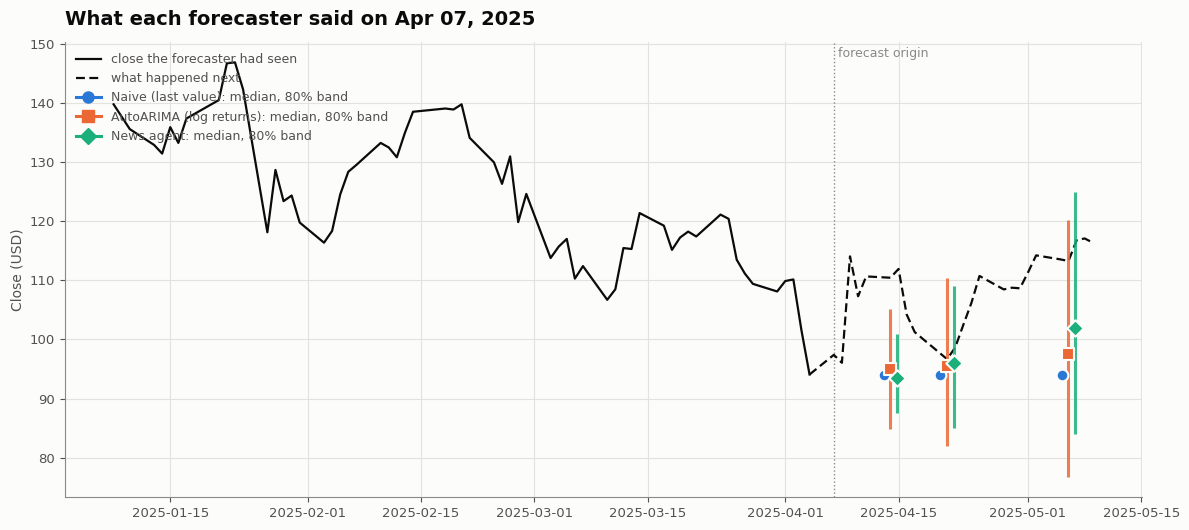

In [5]:
fig, ax = origin_fan(frame, prices, "2025-04-07", predictors=PREDICTORS)

In [6]:
scores_at("2025-04-07")

,predictor,horizon,forecast_date,q10,q50,q90,actual,crps
0,AutoARIMA (log returns),5,2025-04-14,84.88,94.96,105.09,110.43,10.84
1,Naive (last value),5,2025-04-14,94.07,94.07,94.07,110.43,16.36
2,News agent,5,2025-04-14,87.50,93.50,101.00,110.43,13.26
3,AutoARIMA (log returns),10,2025-04-21,82.06,95.56,110.44,96.67,3.08
4,Naive (last value),10,2025-04-21,94.07,94.07,94.07,96.67,2.59
5,News agent,10,2025-04-21,85.00,96.00,109.00,96.67,2.30
6,AutoARIMA (log returns),21,2025-05-06,76.82,97.59,120.18,113.25,9.23
7,Naive (last value),21,2025-05-06,94.07,94.07,94.07,113.25,19.18
8,News agent,21,2025-05-06,84.00,102.00,125.00,113.25,6.86


In [7]:
print(agent_rationale("agent_predictor_nvda_analyst_multitask", "2025-04-07"))

NVDA's recent price action reflects significant downward pressure driven by macro headwinds, geopolitical risks related to export controls, and uncertainty surrounding AI infrastructure sustainability. The forecasts reflect an initial stabilization following an oversold condition at $94.07, transitioning into a measured recovery as the market tests the sustainability of current demand levels.


**What the agent did.** It read the situation correctly (export controls, macro
pressure, an oversold stock) and forecast stabilisation, then recovery. Nobody could
know the tariff pause in advance, so its 5-day forecast missed the rebound, but its
21-day forecast (median \$102, band \$84–\$125) contained the outcome, \$113, and beat
AutoARIMA (CRPS 6.9 against 9.2).

---

## 3. Across all 51 origins

The same three forecasters on every weekly origin of 2025:

In [8]:
from ai_stocks_forecasting.analysis import leaderboard_with_uncertainty


leaderboard_with_uncertainty(frame).round(2)

,mean_crps,se,n,family
predictor,,,,
News agent,8.01,0.52,145,LLM / Agent
AutoARIMA (log returns),8.17,0.32,145,Numerical ML
Naive (last value),10.67,0.62,145,Baseline


## Key takeaways

- **On average the agent ties AutoARIMA** (CRPS 8.01 against 8.17; the gap is well inside
  one standard error) and both beat naive (10.67).
- **It is a different kind of forecaster.** Its intervals are about half as wide, so it
  scores better in quiet weeks and worse when a shock arrives. Notebook 4 measures this.
- **News helps when the story is already visible** (April) and does not when the shock is
  new (January). The agent reasons from what it finds; it does not anticipate.

Next, Notebook 3 shows how the same agent answers a second question, the chance of a
±5% move tomorrow, and what we found when we audited its search tool.